In [14]:
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt
import pandas as pd
import numpy  as np
import math, json, os
pd.set_option('display.max_columns', None)

# CONFIGURAÇÕES

In [15]:
OPTIONS = json.loads(open('../../info.json', 'r', encoding='utf-8').read()).get('target')
OPTIONS

{'test': 5, 'axis': 'x'}

In [16]:
PATH = f'../files/test{OPTIONS['test']}/rolling_{OPTIONS['axis']}'
print(PATH)
print(os.listdir(PATH))

../files/test5/rolling_x
['reference', 'info.json', 'target']


In [17]:
TARGET_VAR = 'pitch'
LIMITS     = json.loads(open(os.path.join(PATH, 'info.json'), 'r').read()).get('limits')
STATIC_LIMITS  = LIMITS.get('static')
DYNAMIC_LIMITS = LIMITS.get('dynamic')

print(LIMITS)
print(STATIC_LIMITS)
print(DYNAMIC_LIMITS)

{'dynamic': [5, 120], 'static': [150, 999999999]}
[150, 999999999]
[5, 120]


# IMPORTANDO DADOS

In [18]:
df = pd.read_csv(f'{PATH}/reference/data.csv')
df

,yaw,time,wz,wy,q1,q3,roll,wx,ay,q2,sample_time,q0,la_pos_mon_d,pitch,ax,az
0,0.6402,9.536743e-07,0.417600,0.001630,-0.6913,0.3212,-1.553,-0.005082,10.200,-0.11700,405000000.0,0.6366,-3.074,0.29960,-0.1211,-0.2074
1,0.6408,4.137588e-02,0.307800,-0.001012,-0.6933,0.3320,-1.553,-0.004250,9.994,-0.10530,505000000.0,0.6309,-3.095,0.33360,-0.1489,-0.1927
2,0.6410,1.444066e-01,0.183500,0.001043,-0.6946,0.3388,-1.554,-0.002836,9.803,-0.09772,605000000.0,0.6271,-3.110,0.35550,-0.1603,-0.1937
3,0.6412,2.432790e-01,0.051080,-0.001338,-0.6950,0.3415,-1.554,0.000067,9.675,-0.09469,705000000.0,0.6256,-3.118,0.36430,-0.1574,-0.2164
4,0.6423,3.413076e-01,-0.082490,-0.018660,-0.6945,0.3405,-1.553,0.002567,9.631,-0.09659,805000000.0,0.6264,-3.119,0.35970,-0.1285,-0.2369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3093,1.2870,3.092585e+02,0.000077,-0.002390,-0.5792,0.4532,-1.552,-0.000261,9.784,-0.39380,705000000.0,0.5514,1.307,0.09078,0.1374,-0.1871
3094,1.2870,3.093545e+02,0.000132,-0.002193,-0.5791,0.4532,-1.552,-0.000100,9.784,-0.39390,805000000.0,0.5514,1.303,0.09078,0.1376,-0.1871
3095,1.2870,3.094505e+02,0.000019,-0.002433,-0.5791,0.4533,-1.552,-0.000305,9.783,-0.39390,905000000.0,0.5513,1.300,0.09077,0.1372,-0.1869
3096,1.2870,3.095561e+02,0.000012,-0.002078,-0.5791,0.4534,-1.552,0.000026,9.784,-0.39400,5000000.0,0.5513,1.296,0.09077,0.1376,-0.1874


- Convertendo pra radianos

In [19]:
for col in ['wx', 'wy', 'wz', 'pitch', 'roll', 'yaw']:
    df.loc[:, col] = df[col] * 180.00/np.pi

df

,yaw,time,wz,wy,q1,q3,roll,wx,ay,q2,sample_time,q0,la_pos_mon_d,pitch,ax,az
0,36.680758,9.536743e-07,23.926718,0.093392,-0.6913,0.3212,-88.980346,-0.291177,10.200,-0.11700,405000000.0,0.6366,-3.074,17.165816,-0.1211,-0.2074
1,36.715136,4.137588e-02,17.635641,-0.057983,-0.6933,0.3320,-88.980346,-0.243507,9.994,-0.10530,505000000.0,0.6309,-3.095,19.113872,-0.1489,-0.1927
2,36.726595,1.444066e-01,10.513776,0.059759,-0.6946,0.3388,-89.037641,-0.162491,9.803,-0.09772,605000000.0,0.6271,-3.110,20.368650,-0.1603,-0.1937
3,36.738054,2.432790e-01,2.926668,-0.076662,-0.6950,0.3415,-89.037641,0.003826,9.675,-0.09469,705000000.0,0.6256,-3.118,20.872852,-0.1574,-0.2164
4,36.801079,3.413076e-01,-4.726329,-1.069139,-0.6945,0.3405,-88.980346,0.147078,9.631,-0.09659,805000000.0,0.6264,-3.119,20.609292,-0.1285,-0.2369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3093,73.739668,3.092585e+02,0.004392,-0.136937,-0.5792,0.4532,-88.923050,-0.014948,9.784,-0.39380,705000000.0,0.5514,1.307,5.201311,0.1374,-0.1871
3094,73.739668,3.093545e+02,0.007546,-0.125650,-0.5791,0.4532,-88.923050,-0.005741,9.784,-0.39390,805000000.0,0.5514,1.303,5.201311,0.1376,-0.1871
3095,73.739668,3.094505e+02,0.001083,-0.139401,-0.5791,0.4533,-88.923050,-0.017469,9.783,-0.39390,905000000.0,0.5513,1.300,5.200738,0.1372,-0.1869
3096,73.739668,3.095561e+02,0.000704,-0.119061,-0.5791,0.4534,-88.923050,0.001478,9.784,-0.39400,5000000.0,0.5513,1.296,5.200738,0.1376,-0.1874


In [20]:
removed = df[df.duplicated(subset=['time'], keep='first')]
df      = df.drop_duplicates(subset=['time'], keep='first')
removed

,yaw,time,wz,wy,q1,q3,roll,wx,ay,q2,sample_time,q0,la_pos_mon_d,pitch,ax,az


# VISUALIZAÇÃO DE VARIÁVEIS

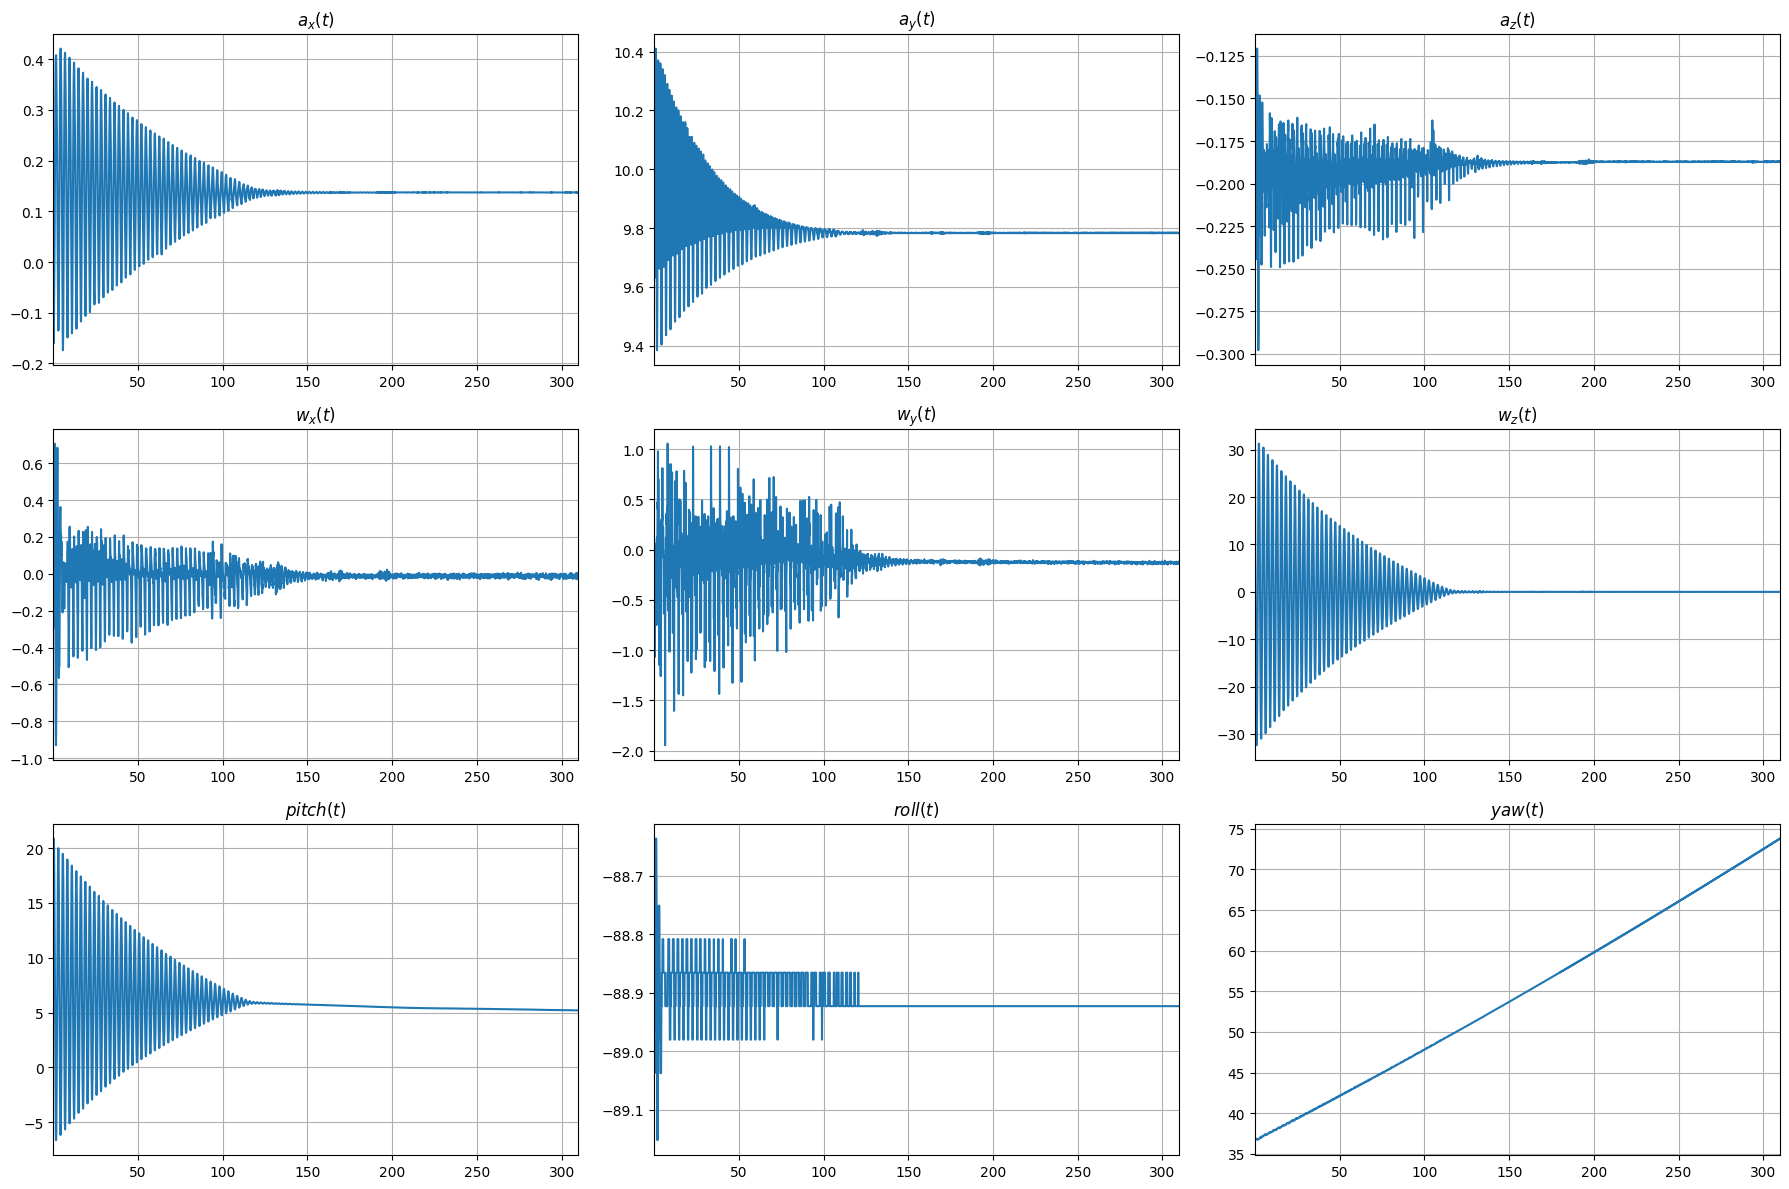

In [21]:
def compareAxis(time, data, limits=(0, 1), yLim=None):
    t_min, t_max = time.min(), time.max()
    delta = t_max - t_min
    
    start_time = t_min + (delta * limits[0])
    end_time   = t_min + (delta * limits[1])
    
    count   = len(data.keys())
    numCols = 3 if count >= 3 else count
    numRows = math.ceil(count / numCols)
    plt.figure(figsize=(6*numCols, 4*numRows))

    for i, (key, values) in enumerate(data.items()):
        mask = (time >= start_time) & (time <= end_time)
        target_time = time[mask]
        target_vals = values[mask]

        plt.subplot(numRows, numCols, i+1)
        plt.plot(target_time, target_vals)
        
        plt.xlim(start_time, end_time) 
        if yLim: plt.ylim(yLim)
        plt.title(key)
        plt.grid(True)

    plt.tight_layout()
    plt.show()

def plotAll(df, limits=(0, 1)):
    compareAxis(df.time, {
        '$a_x(t)$': df.ax, '$a_y(t)$': df.ay, '$a_z(t)$': df.az,
        '$w_x(t)$': df.wx, '$w_y(t)$': df.wy, '$w_z(t)$': df.wz,
        '$pitch(t)$': df.pitch, '$roll(t)$': df.roll, '$yaw(t)$': df.yaw
    }, limits)


plotAll(df, limits=(0, 1))

# AMOSTRAGEM

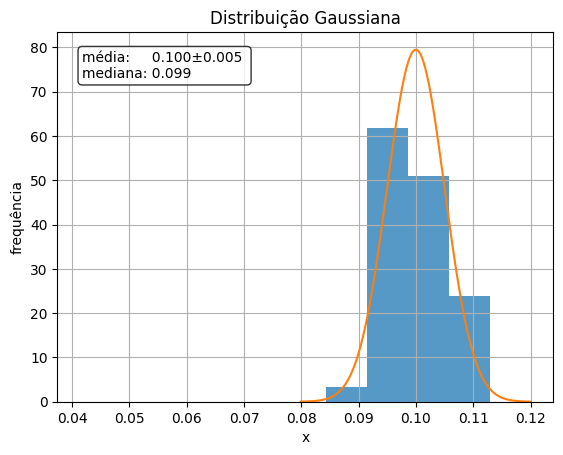

,time,yaw,wz,wy,q1,q3,roll,wx,ay,q2,sample_time,q0,la_pos_mon_d,pitch,ax,az
0,0.0,36.680758,23.926718,0.093392,-0.6913,0.3212,-88.980346,-0.291177,10.200,-0.11700,405000000.0,0.6366,-3.074,17.165816,-0.1211,-0.2074
1,0.1,36.715136,17.635641,-0.057983,-0.6933,0.3320,-88.980346,-0.243507,9.994,-0.10530,505000000.0,0.6309,-3.095,19.113872,-0.1489,-0.1927
2,0.2,36.726595,10.513776,0.059759,-0.6946,0.3388,-89.037641,-0.162491,9.803,-0.09772,605000000.0,0.6271,-3.110,20.368650,-0.1603,-0.1937
3,0.3,36.738054,2.926668,-0.076662,-0.6950,0.3415,-89.037641,0.003826,9.675,-0.09469,705000000.0,0.6256,-3.118,20.872852,-0.1574,-0.2164
4,0.4,36.801079,-4.726329,-1.069139,-0.6945,0.3405,-88.980346,0.147078,9.631,-0.09659,805000000.0,0.6264,-3.119,20.609292,-0.1285,-0.2369
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3093,309.3,73.739668,0.004392,-0.136937,-0.5792,0.4532,-88.923050,-0.014948,9.784,-0.39380,705000000.0,0.5514,1.307,5.201311,0.1374,-0.1871
3094,309.4,73.739668,0.007546,-0.125650,-0.5791,0.4532,-88.923050,-0.005741,9.784,-0.39390,805000000.0,0.5514,1.303,5.201311,0.1376,-0.1871
3095,309.5,73.739668,0.001083,-0.139401,-0.5791,0.4533,-88.923050,-0.017469,9.783,-0.39390,905000000.0,0.5513,1.300,5.200738,0.1372,-0.1869
3096,309.6,73.739668,0.000704,-0.119061,-0.5791,0.4534,-88.923050,0.001478,9.784,-0.39400,5000000.0,0.5513,1.296,5.200738,0.1376,-0.1874


In [22]:
def gaussian(data):
    data  = np.array(data)
    n     = data.shape[0]
    mu    = data.mean()
    sigma = data.std()

    x  = np.linspace(mu - 4*sigma, mu + 4*sigma, 400)
    y  = (1/(sigma*np.sqrt(2*np.pi))) * np.exp(-0.5*((x - mu)/sigma)**2)
    plt.title(f'Distribuição Gaussiana')
    plt.hist(data, density=True, alpha=0.75)
    plt.plot(x, y)
    
    text = f'média:     {mu:.3f}±{sigma:.3f} \nmediana: {np.median(data):.3f}'
    opts = dict(boxstyle='round', facecolor='white', alpha=0.8)
    plt.text(0.05, 0.95, text, transform=plt.gca().transAxes, verticalalignment='top', bbox=opts)
    plt.xlabel('x'); plt.ylabel('frequência'); plt.grid()

def normalizePeriod(df, key, dt=0.15):
    df = df.copy().sort_values(key)
    df[key] = df[key] - df[key].iloc[0]

    initTime  = df[key].iloc[0]
    finalTime = df[key].iloc[-1] + dt
    n = int(np.floor((finalTime - initTime) / dt)) + 1
    newAxis = np.round(np.linspace(initTime, initTime + dt*(n-1), n), 10)
    target  = pd.DataFrame({key: newAxis})
    out = pd.merge_asof(target, df, on=key, direction='backward')
    return out


time = df.time.diff()[1:].to_numpy()
dt   = np.median(time).round(2)
dt = 0.10
gaussian(time); plt.show()
df = normalizePeriod(df, 'time', dt)
df

# SEPARAÇÃO DE TABELAS
- Juntando Amostragem pelos limites definidos

In [23]:
df_static  = df.loc[(df.time >= STATIC_LIMITS[0]) & (df.time <= STATIC_LIMITS[1])].copy()
df_dynamic = df.loc[(df.time > DYNAMIC_LIMITS[0]) & (df.time <= DYNAMIC_LIMITS[1])].copy() 

df_dynamic['static'] = False
df_static['static']  = True

df_dynamic.loc[:, 'time'] = (df_dynamic.time - df_dynamic.time.values[0])
df_static.loc[:, 'time']  = (df_static.time  - df_static.time.values[0])  + df_dynamic.time.values[-1]

df = pd.concat([df_dynamic, df_static], axis=0, ignore_index=True)
df

,time,yaw,wz,wy,q1,q3,roll,wx,ay,q2,sample_time,q0,la_pos_mon_d,pitch,ax,az,static
0,0.0,37.247986,29.759428,-0.075630,-0.6806,0.2854,-88.808458,0.049085,10.340,-0.1632,505000000.0,0.6548,-3.240,10.061139,0.128400,-0.1994,False
1,0.1,37.247986,27.427490,0.195722,-0.6845,0.3011,-88.808458,0.037546,10.310,-0.1461,605000000.0,0.6476,-3.257,12.880091,0.062020,-0.1900,False
2,0.2,37.265175,23.531377,0.226777,-0.6877,0.3148,-88.808458,-0.130634,10.180,-0.1312,705000000.0,0.6410,-3.276,15.349539,-0.006405,-0.1802,False
3,0.3,37.282364,18.409134,0.211479,-0.6900,0.3257,-88.808458,-0.155845,10.030,-0.1191,805000000.0,0.6354,-3.295,17.343432,-0.063050,-0.1864,False
4,0.4,37.305282,12.186812,0.004055,-0.6915,0.3334,-88.865754,-0.209301,9.865,-0.1107,905000000.0,0.6312,-3.310,18.735720,-0.113800,-0.1910,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,73.739668,0.004392,-0.136937,-0.5792,0.4532,-88.923050,-0.014948,9.784,-0.3938,705000000.0,0.5514,1.307,5.201311,0.137400,-0.1871,True
2744,274.3,73.739668,0.007546,-0.125650,-0.5791,0.4532,-88.923050,-0.005741,9.784,-0.3939,805000000.0,0.5514,1.303,5.201311,0.137600,-0.1871,True
2745,274.4,73.739668,0.001083,-0.139401,-0.5791,0.4533,-88.923050,-0.017469,9.783,-0.3939,905000000.0,0.5513,1.300,5.200738,0.137200,-0.1869,True
2746,274.5,73.739668,0.000704,-0.119061,-0.5791,0.4534,-88.923050,0.001478,9.784,-0.3940,5000000.0,0.5513,1.296,5.200738,0.137600,-0.1874,True


# FILTRANDO POR VARIAVEL

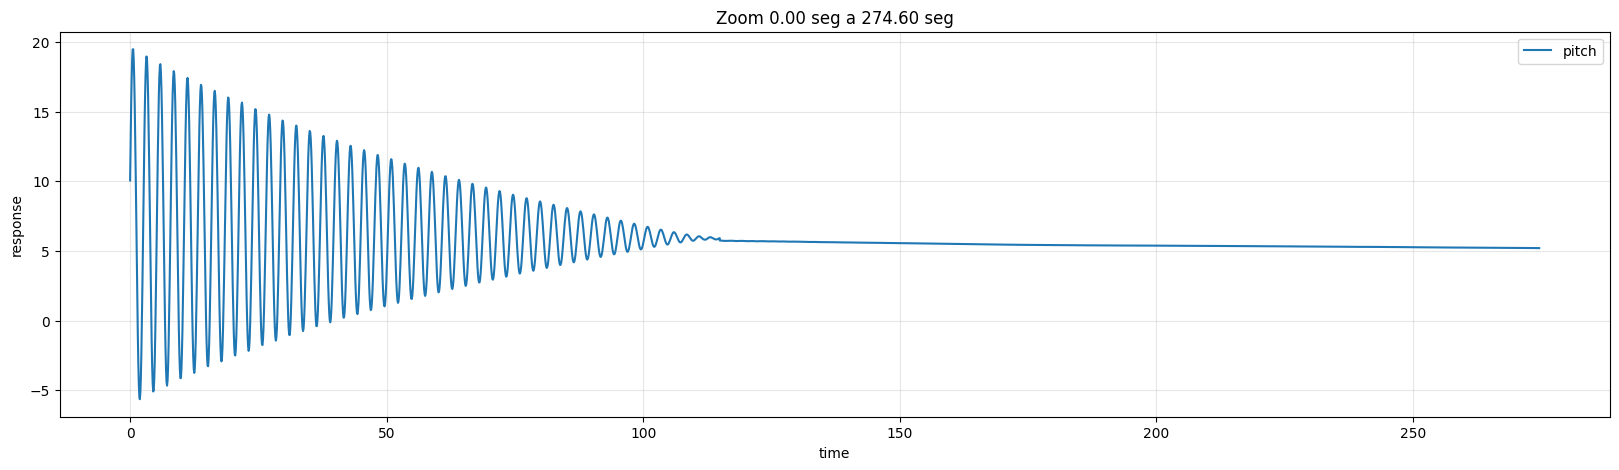

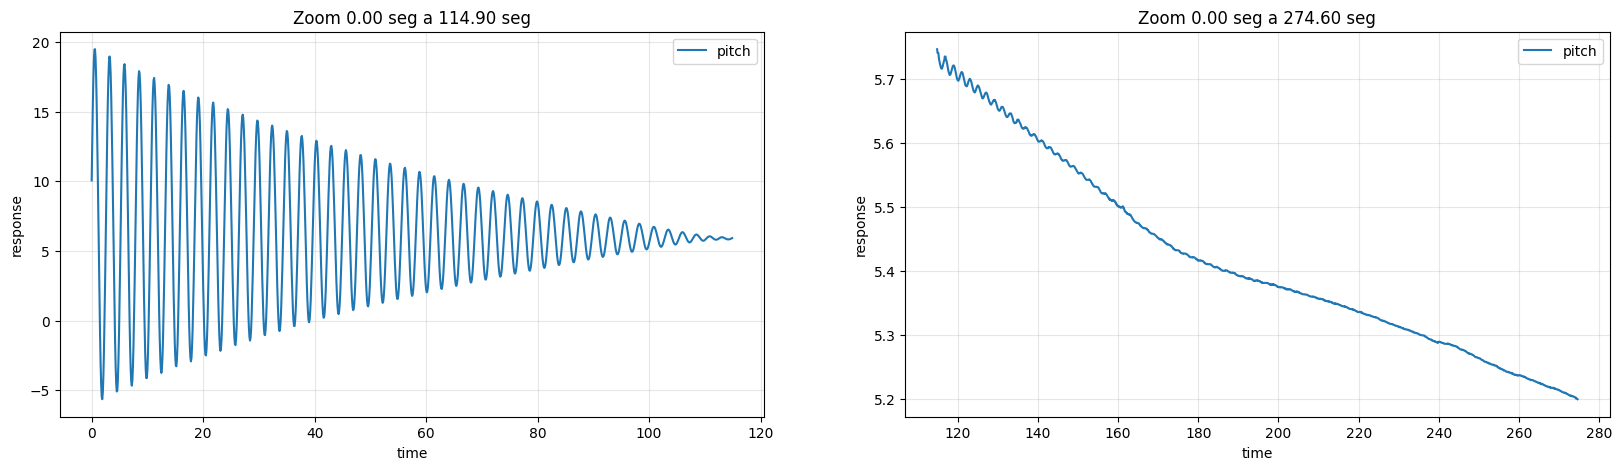

In [24]:
def plotViews(df, limits=(0, 1)):
    VIEW_TIME = (df.time.values[-1]*limits[0], df.time.values[-1]*limits[1])
    target    = df.loc[(df.time >= VIEW_TIME[0]) & (df.time <= VIEW_TIME[1])]

    plt.plot(target.time, target[TARGET_VAR], label=TARGET_VAR)
    plt.grid(alpha=.3); plt.legend(); plt.xlabel('time'); plt.ylabel('response')
    plt.title(f'Zoom {' a '.join([f'{val:.2f} seg' for val in df.time.max()*np.array(limits)])}')


plt.figure(figsize=(20, 5))
plotViews(df, limits=(0, 1))

plt.figure(figsize=(20, 5))
plt.subplot(1, 2, 1)
plotViews(df_dynamic, limits=(0, 1))

plt.subplot(1, 2, 2)
plotViews(df_static, limits=(0, 1))

# SALVANDO DADOS

In [25]:
df = df.rename(columns={col: 'ref_' + col for col in df.columns if col not in ['time', 'static']})
df

,time,ref_yaw,ref_wz,ref_wy,ref_q1,ref_q3,ref_roll,ref_wx,ref_ay,ref_q2,ref_sample_time,ref_q0,ref_la_pos_mon_d,ref_pitch,ref_ax,ref_az,static
0,0.0,37.247986,29.759428,-0.075630,-0.6806,0.2854,-88.808458,0.049085,10.340,-0.1632,505000000.0,0.6548,-3.240,10.061139,0.128400,-0.1994,False
1,0.1,37.247986,27.427490,0.195722,-0.6845,0.3011,-88.808458,0.037546,10.310,-0.1461,605000000.0,0.6476,-3.257,12.880091,0.062020,-0.1900,False
2,0.2,37.265175,23.531377,0.226777,-0.6877,0.3148,-88.808458,-0.130634,10.180,-0.1312,705000000.0,0.6410,-3.276,15.349539,-0.006405,-0.1802,False
3,0.3,37.282364,18.409134,0.211479,-0.6900,0.3257,-88.808458,-0.155845,10.030,-0.1191,805000000.0,0.6354,-3.295,17.343432,-0.063050,-0.1864,False
4,0.4,37.305282,12.186812,0.004055,-0.6915,0.3334,-88.865754,-0.209301,9.865,-0.1107,905000000.0,0.6312,-3.310,18.735720,-0.113800,-0.1910,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2743,274.2,73.739668,0.004392,-0.136937,-0.5792,0.4532,-88.923050,-0.014948,9.784,-0.3938,705000000.0,0.5514,1.307,5.201311,0.137400,-0.1871,True
2744,274.3,73.739668,0.007546,-0.125650,-0.5791,0.4532,-88.923050,-0.005741,9.784,-0.3939,805000000.0,0.5514,1.303,5.201311,0.137600,-0.1871,True
2745,274.4,73.739668,0.001083,-0.139401,-0.5791,0.4533,-88.923050,-0.017469,9.783,-0.3939,905000000.0,0.5513,1.300,5.200738,0.137200,-0.1869,True
2746,274.5,73.739668,0.000704,-0.119061,-0.5791,0.4534,-88.923050,0.001478,9.784,-0.3940,5000000.0,0.5513,1.296,5.200738,0.137600,-0.1874,True


In [26]:
os.makedirs('output', exist_ok=True)
df.to_csv('output/data.csv', index=None)